# Data Visualization

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# found from recitations.
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:.2f}'.format

# this loads the datas.
burnout = pd.read_csv('burnout_processed.csv')
health  = pd.read_csv('health_processed.csv', parse_dates=['date'])

## 1. Feature Distributions (Burnout Dataset)

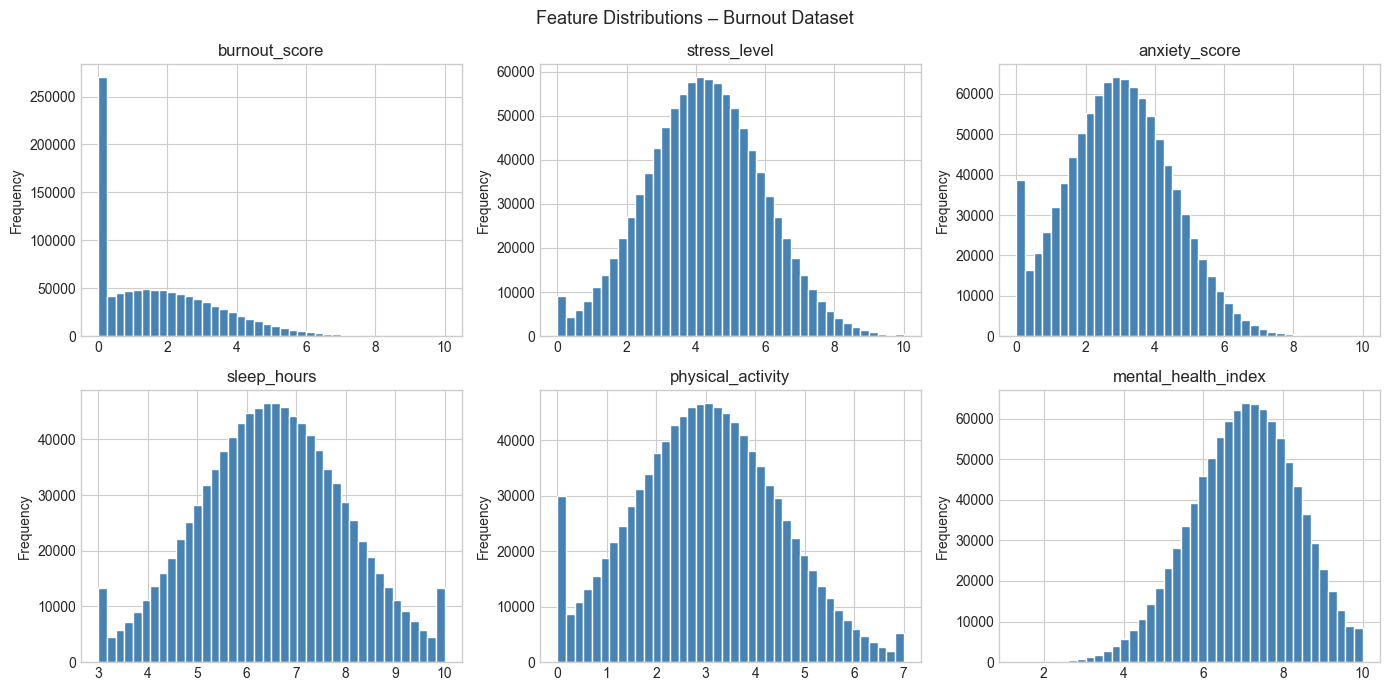

In [19]:
# setting the graph names (column_names)
cols = ['burnout_score','stress_level','anxiety_score',
        'sleep_hours','physical_activity','mental_health_index']

# Create a 2x3 grid of subplots to visualize distrubitiobns.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), cols):
    burnout[col].plot(kind='hist', bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    
plt.suptitle('Feature Distributions – Burnout Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('plots/01_distributions.png', dpi=150)
plt.show()

## 2. Correlation Heatmap (Burnout Dataset)

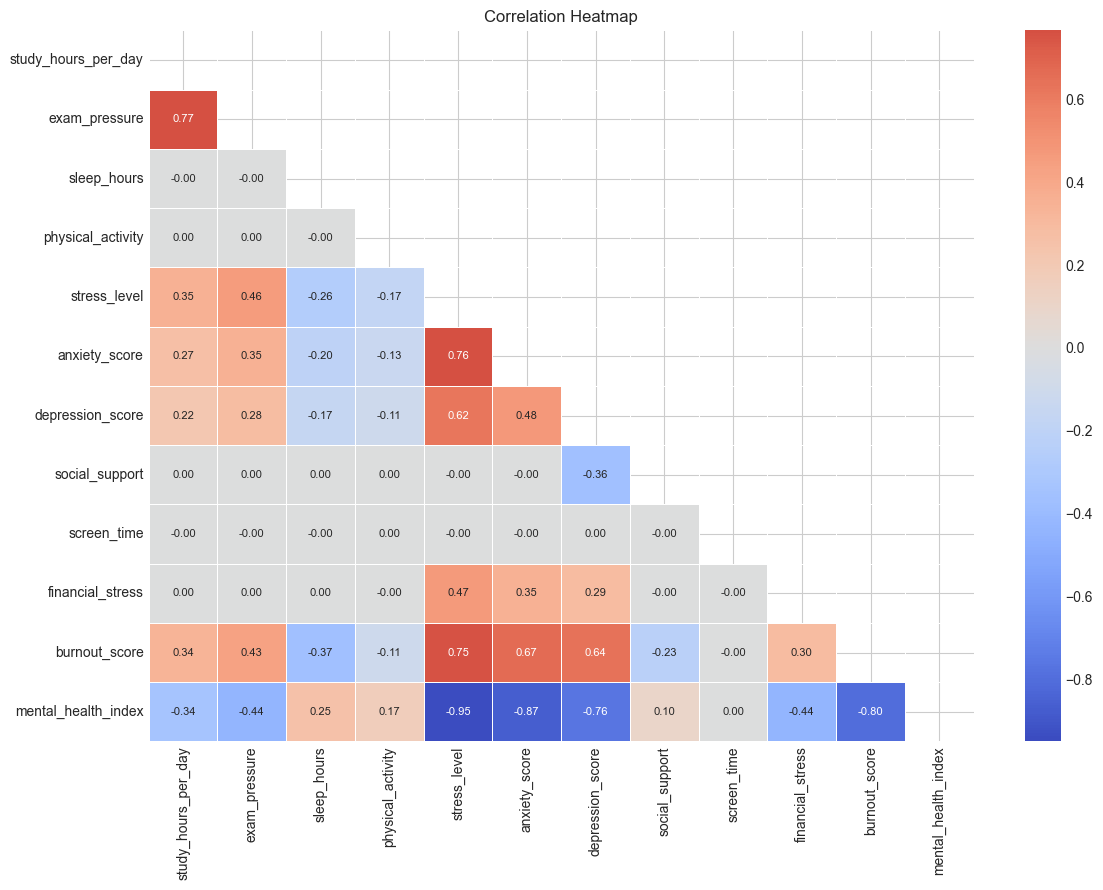

In [20]:
# setting the graph names (heatmap names at the left side.)
num_cols = ['study_hours_per_day','exam_pressure','sleep_hours','physical_activity',
            'stress_level','anxiety_score','depression_score','social_support',
            'screen_time','financial_stress','burnout_score','mental_health_index']

# calculate the pearson correlation corr
corr = burnout[num_cols].corr()
# initialize the matplotlib figure and set a feasible size args.
fig, ax = plt.subplots(figsize=(12, 9))
# creating a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# creating the heatmap and setting the colormap as coolwarm because i'm colorblind :(
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8}, ax=ax)
# saving and showing the final heatmap
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/02_correlation.png', dpi=150)
plt.show()

## 3. Physical Activity vs Burnout (KDEplot) (Burnout Dataset)

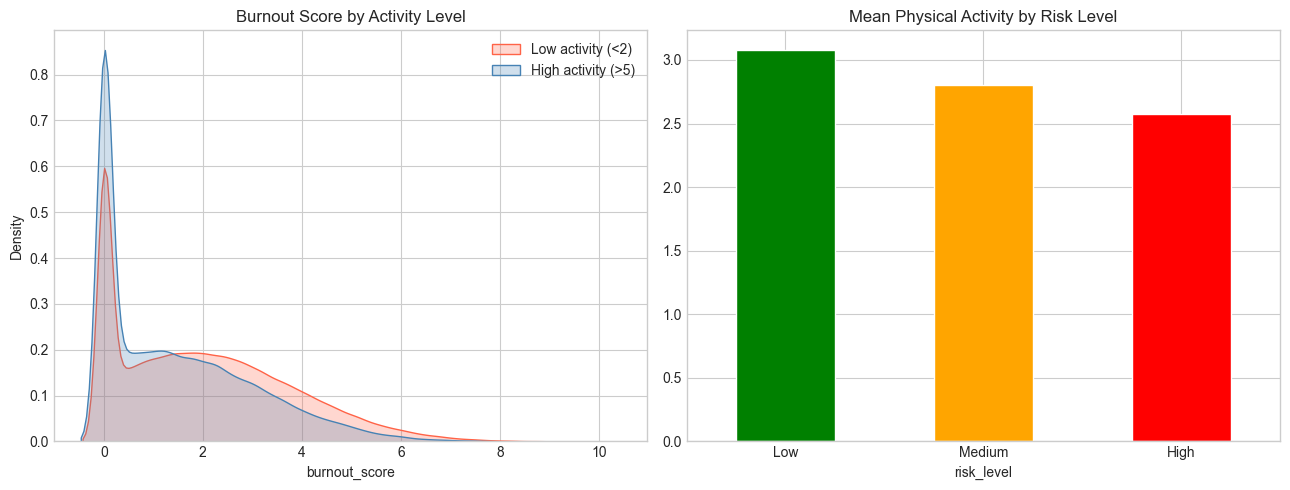

In [21]:
# seperating activity by <2 and >5 for resarch.
low_activity_score  = burnout.query('physical_activity < 2')['burnout_score']
high_activity_score = burnout.query('physical_activity > 5')['burnout_score']

# set the visualization space with two side to side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# left side
sns.kdeplot(low_activity_score,  fill=True, label='Low activity (<2)',  ax=axes[0], color='tomato')
sns.kdeplot(high_activity_score, fill=True, label='High activity (>5)', ax=axes[0], color='steelblue')
axes[0].set_title('Burnout Score by Activity Level')
axes[0].legend()
# right side
risk_colors = ['green', 'orange', 'red']
burnout.groupby('risk_level')['physical_activity'].mean().reindex(['Low','Medium','High']).plot(
    kind='bar', 
    ax=axes[1], 
    color=risk_colors, 
    edgecolor='white'
)

# saving the figure and adjustnig it. then showing it.
axes[1].set_title('Mean Physical Activity by Risk Level')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('plots/03_activity_burnout.png', dpi=150)
plt.show()

## 4. My Personal Metrics – Time Series (Apple Health Data)

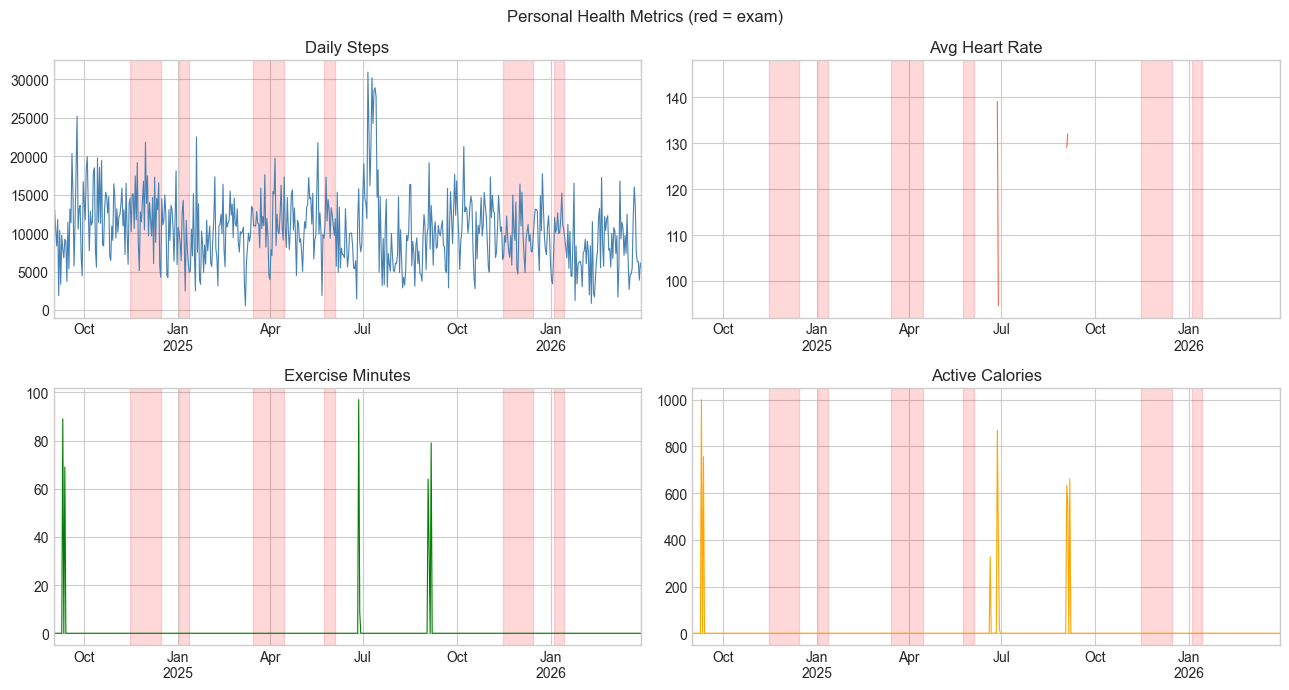

In [22]:
# defining specific exam dates of sabanci university midterms 
# (parsed from academic calendar and some approximation.)
exam_periods = [
    ('2025-01-02','2025-01-12'), ('2025-05-24','2025-06-04'),
    ('2026-01-04','2026-01-14'), ('2024-11-15','2024-12-15'),
    ('2025-03-15','2025-04-15'), ('2025-11-15','2025-12-15'),
]

# columns
metrics = [('daily_steps','steelblue','Daily Steps'),
           ('avg_heart_rate','tomato','Avg Heart Rate'),
           ('exercise_minutes','green','Exercise Minutes'),
           ('active_calories','orange','Active Calories')]
# setting the plot
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# creating the graphs
for ax, (col, color, label) in zip(axes.flatten(), metrics):
    health.set_index('date')[col].plot(ax=ax, color=color, linewidth=0.8)
    for s, e in exam_periods:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color='red')
    ax.set_title(label)
    ax.set_xlabel('')

# saving and showing the plot.
plt.suptitle('Personal Health Metrics (red = exam)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/04_timeseries.png', dpi=150)
plt.show()

## 5. Exam vs Non-Exam – Box Plot (Apple Health Data)

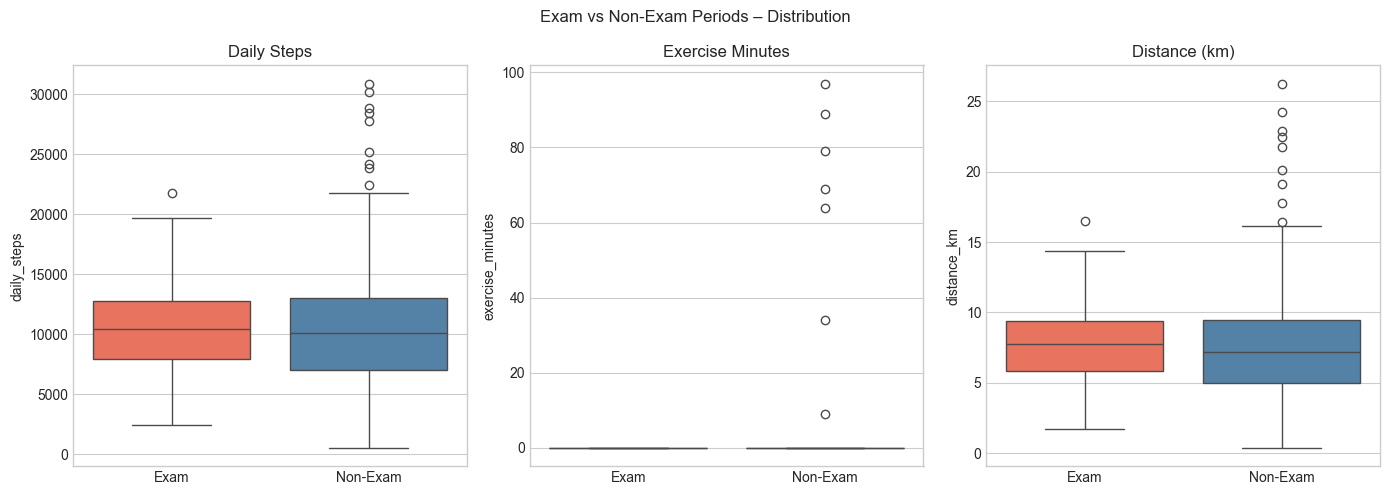

In [23]:
# creating exam vs nonexam periods for comparing.
exam    = health[health['is_exam_period'] == 1].copy()
nonexam = health[health['is_exam_period'] == 0].copy()
exam['Period']    = 'Exam'
nonexam['Period'] = 'Non-Exam'
combined = pd.concat([exam, nonexam])
# creating 3 plots.
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
# adding items to the plots.
for ax, col, label in zip(axes,
                           ['daily_steps', 'exercise_minutes', 'distance_km'],
                           ['Daily Steps', 'Exercise Minutes', 'Distance (km)']):
    sns.boxplot(data=combined, x='Period', y=col, hue='Period', ax=ax,
                palette={'Exam': 'tomato', 'Non-Exam': 'steelblue'}, legend=False)
    ax.set_title(label)
    ax.set_xlabel('')
# saving and showing the plot.
plt.suptitle('Exam vs Non-Exam Periods – Distribution', fontsize=12)
plt.tight_layout()
plt.savefig('plots/05_boxplot_exam.png', dpi=150)
plt.show()

## 6. Personal vs Population

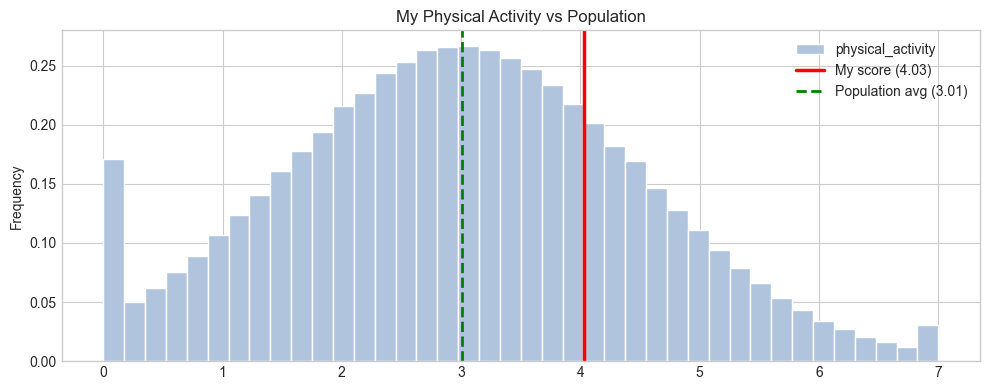

In [24]:
# getting the mean of people and myself's activity routines.
my_activity  = health['physical_activity_normalized'].mean()
pop_activity = burnout['physical_activity'].mean()
# creating the plot.
fig, ax = plt.subplots(figsize=(10, 4))
burnout['physical_activity'].plot(kind='hist', bins=40, ax=ax,
                                   color='lightsteelblue', edgecolor='white', density=True)
ax.axvline(my_activity,  color='red',   lw=2.5, label=f'My score ({my_activity:.2f})')
ax.axvline(pop_activity, color='green', lw=2,   linestyle='--',
           label=f'Population avg ({pop_activity:.2f})')

# setting and saving and showing the plot
ax.set_title('My Physical Activity vs Population')
ax.legend()
plt.tight_layout()
plt.savefig('plots/06_personal_vs_population.png', dpi=150)
plt.show()